<a href="https://colab.research.google.com/github/suvidhakarkera/HospitalReadmissionPredicition/blob/main/Feature_Extraction_%26_Conventional_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports and Installs

In [1]:
! pip install opencv-python --quiet
!pip install matplotlib --quiet

In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
from google.colab import files
uploaded = files.upload()

# Get the name of the uploaded image
image_path = next(iter(uploaded))

print("Uploaded image:", image_path)

Saving 11121_214076108763640a4e1d303.webp to 11121_214076108763640a4e1d303 (1).webp
Uploaded image: 11121_214076108763640a4e1d303 (1).webp


# Load the Image

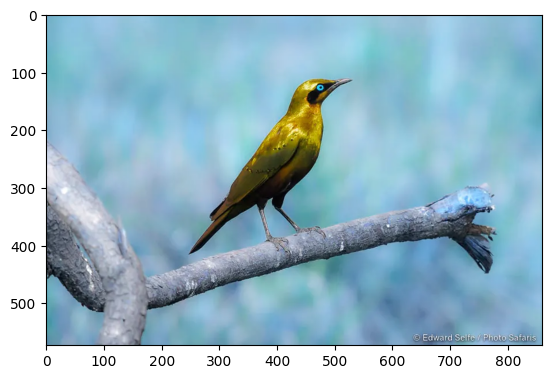

In [4]:
image_path = Path(image_path)

if not image_path.exists():
    raise FileNotFoundError(f"Image not found : {image_path}")

#opencv reads images in BGR format
raw_image_bgr = cv2.imread(str(image_path))

if raw_image_bgr is None:
  raise ValueError("This file could not be read as an Image")

plt.imshow(raw_image_bgr)

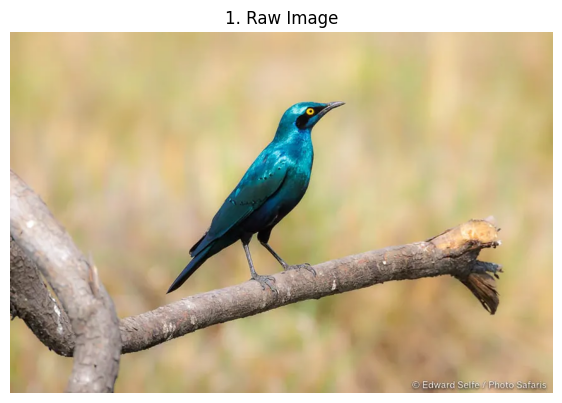

In [5]:
# Convert BGR to RGB for correct display using Matplotlib
raw_image_rgb = cv2.cvtColor(raw_image_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(7, 5))
plt.imshow(raw_image_rgb)
plt.title("1. Raw Image")
plt.axis("off")
plt.show()

In [6]:
print("Image loaded successfully")
print("Image shape:",raw_image_rgb.shape)
print("Data type:", raw_image_rgb.dtype)
print("Minimum pixel value:", raw_image_rgb.min())
print("Maximum pixel value:", raw_image_rgb.max())

Image loaded successfully
Image shape: (573, 860, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


# Part 1 : Image Preprocessing

## **Step 1: Resize the image**


> Different images may have different dimensions. Traditional ML models require every image to produce the same number of features.




Original Shape:  (573, 860, 3)
Resized Shape:  (500, 700, 3)


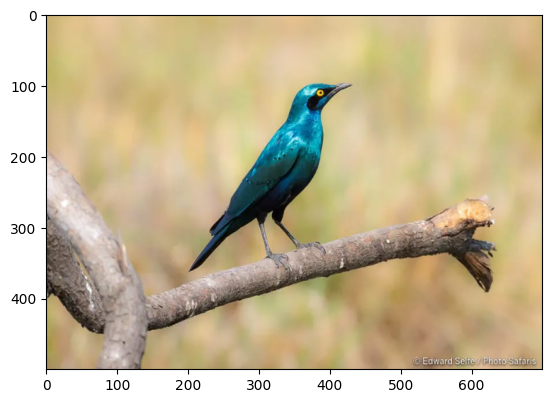

In [14]:
target_height = 700
target_width = 500

# use the resize function explained before and pass the image, target_height and target_width as function inputs.

resized_img = cv2.resize(raw_image_rgb,(target_height,target_width))


print("Original Shape: ", raw_image_rgb.shape)
print("Resized Shape: ", resized_img.shape)
plt.imshow(resized_img)

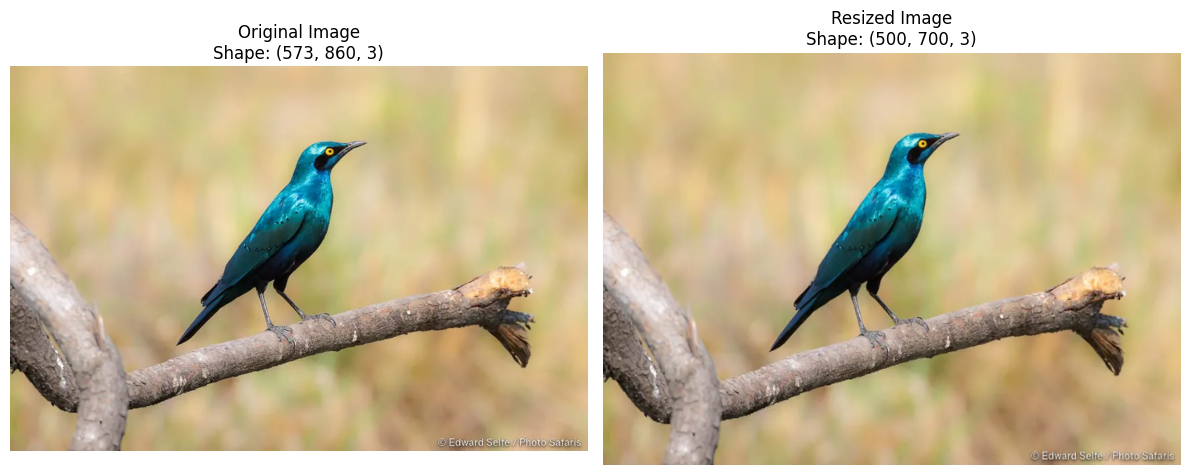

In [15]:
#side by side comparision
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(raw_image_rgb)
plt.title(f"Original Image\nShape: {raw_image_rgb.shape}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized_img)
plt.title(f"Resized Image\nShape: {resized_img.shape}")
plt.axis("off")

plt.tight_layout()
plt.show()

## **Step 2: Convert to grayscale**


> A colour image has three channels: Red, Green, Blue. A grayscale image has only one channel representing brightness.






Original Shape:  (500, 700, 3)
Grayscale Shape:  (573, 860)


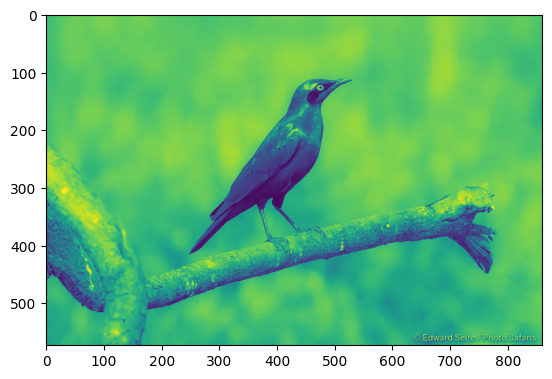

In [16]:
# use the resize function explained before and pass the resized image
grayscale_img = cv2.cvtColor(resized_img,cv2.COLOR_RGB2GRAY)


print("Original Shape: ", resized_img.shape)
print("Grayscale Shape: ", grayscale_img.shape)

plt.imshow(grayscale_img)

- **cv2.COLOR_RGB2GRAY** does convert the image data to grayscale. The unusual green, yellow, and purple appearance comes from how matplotlib displays a 2D array.

- Matplotlib sees a two-dimensional matrix of intensity values and applies its default colour map, usually viridis:

1. Low intensities → purple
2. Medium intensities → green
3. High intensities → yellow

> This is called pseudocolouring. Your image is still grayscale numerically; Matplotlib is only displaying it using artificial colours.

Here, cmap="gray" tells Matplotlib:
Display low pixel values as black and high pixel values as white.








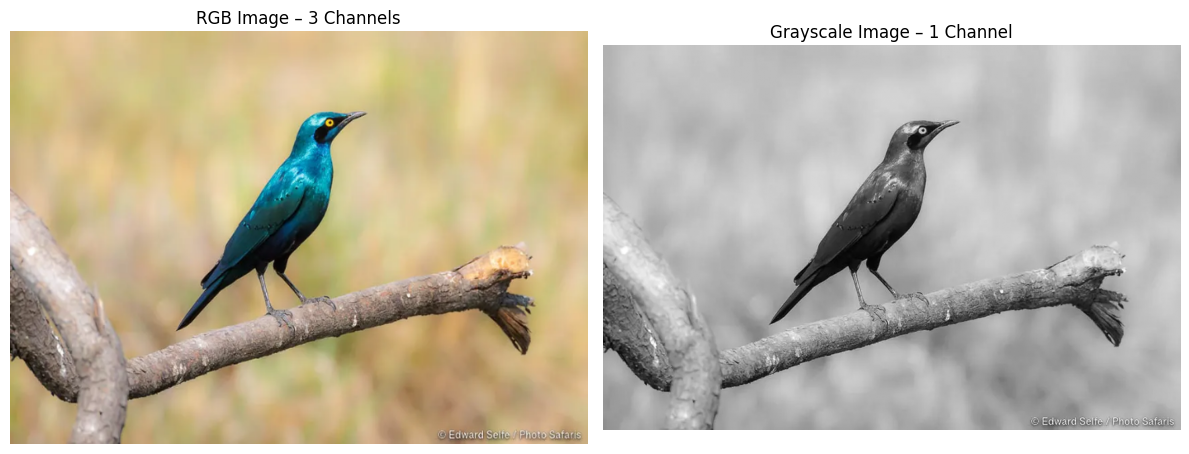

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(resized_img)
plt.title("RGB Image – 3 Channels")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(grayscale_img, cmap="gray")
plt.title("Grayscale Image – 1 Channel")
plt.axis("off")

plt.tight_layout()
plt.show()

- Therefore, grayscale conversion reduces the amount of data by approximately three times.

- Grayscale should only be used when colour is not an important feature.

For example:
1. Handwritten digit recognition: colour is usually not important.
2. Fruit-ripeness classification: colour may be very important.

## **Step 3: Normalize pixel values**

Before normalization
Datatype:  uint8
Minimum Value: 0
Maximum Value: 255

After normalization
Datatype:  float64
Minimum Value: 0.0
Maximum Value: 1.0


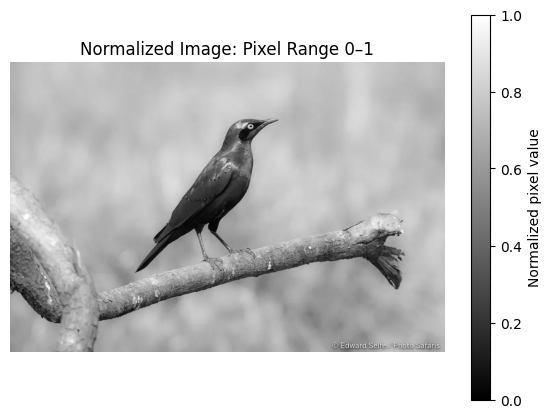

In [18]:
normalized_img = grayscale_img/255.0

print("Before normalization")
print("Datatype: ", grayscale_img.dtype)
print('Minimum Value:', grayscale_img.min())
print('Maximum Value:', grayscale_img.max())

print("\nAfter normalization")
print("Datatype: ", normalized_img.dtype)
print('Minimum Value:', normalized_img.min())
print('Maximum Value:', normalized_img.max())

plt.figure(figsize=(7, 5))
plt.imshow(normalized_img, cmap="gray")
plt.title("Normalized Image: Pixel Range 0–1")
plt.axis("off")
plt.colorbar(label="Normalized pixel value")
plt.show()

## **Step 4: Denoise or blur the image**

> A small amount of Gaussian blur can reduce random noise and minor pixel variations.



Blurred image shape:  (573, 860)
Minimum Value: 0.016743259803921568
Maximum Value: 0.9971200980392156


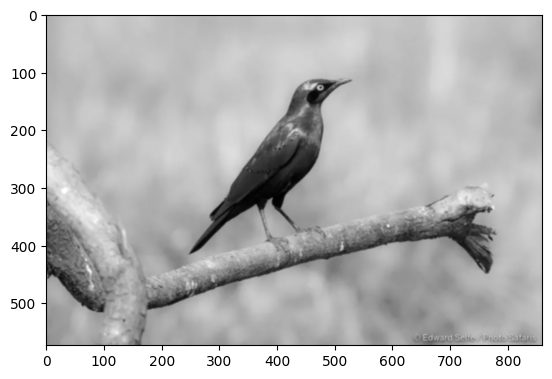

In [19]:
# Apply Gaussian blur

blurred_img = cv2.GaussianBlur(normalized_img,(5,5),0)

print("Blurred image shape: ", blurred_img.shape)
print("Minimum Value:", blurred_img.min())
print("Maximum Value:", blurred_img.max())
plt.imshow(blurred_img, cmap="gray")


> (5, 5) is the kernel size.          
It means that OpenCV examines a small 5 × 5 region around each pixel and calculates a weighted average.

A larger kernel creates stronger blurring.

Blurring can:
- Reduce random noise
- Smooth small variations
- Help some edge and contour algorithms


> Too much blurring can remove useful information. Therefore, preprocessing should remain simple and task-specific.




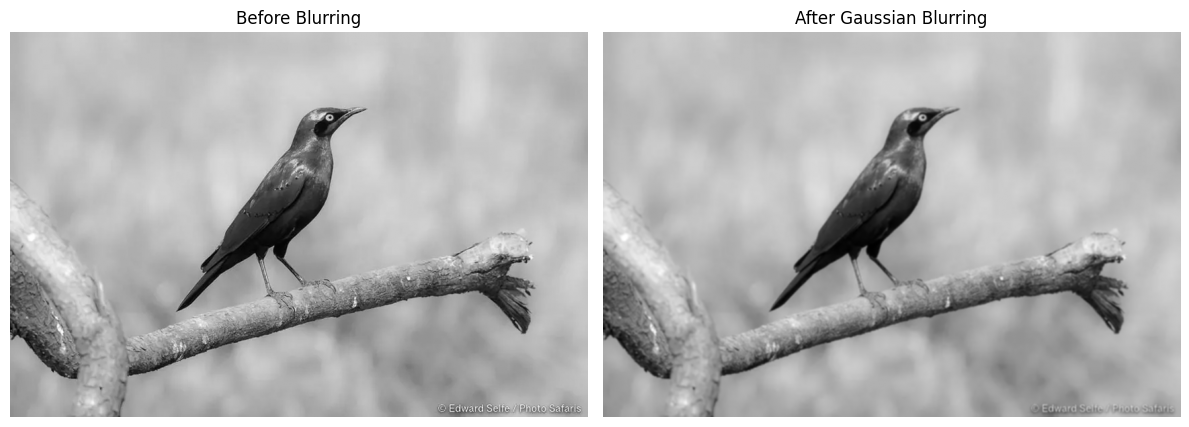

In [20]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(normalized_img, cmap="gray")
plt.title("Before Blurring")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred_img, cmap="gray")
plt.title("After Gaussian Blurring")
plt.axis("off")

plt.tight_layout()
plt.show()

## **Step 5: Flatten the image**

> Machine-learning models generally expect data in tabular form:                       
> samples × features.           
>     Currently, the image is a two-dimensional matrix: We will convert it into a one-dimensional vector.




In [21]:
flat_img = blurred_img.flatten()

print("Image before flattening:", blurred_img.shape)
print("Image after flattening:", flat_img.shape)
print("Number of Features:", flat_img.size)


Image before flattening: (573, 860)
Image after flattening: (492780,)
Number of Features: 492780


In [22]:
print("First 20 flattened pixel features:")
print(flat_img[:20])

First 20 flattened pixel features:
[0.69803922 0.69803922 0.69803922 0.69803922 0.69803922 0.69803922
 0.69803922 0.69803922 0.69828431 0.69926471 0.70122549 0.70416667
 0.70784314 0.71176471 0.71519608 0.71715686 0.71789216 0.71887255
 0.72058824 0.72254902]




> Each number is now treated as one input feature.



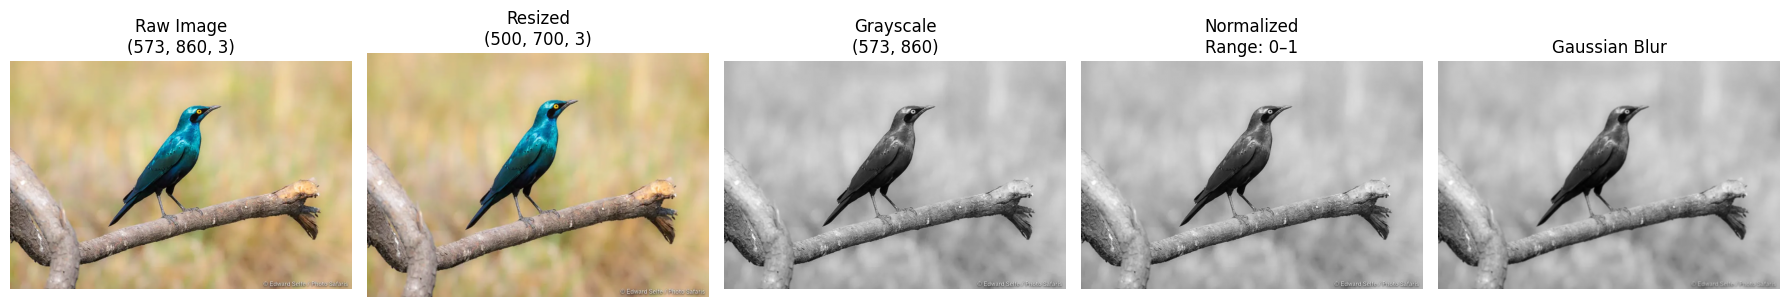

In [23]:
images = [
    raw_image_rgb,
    resized_img,
    grayscale_img,
    normalized_img,
    blurred_img
]

titles = [
    f"Raw Image\n{raw_image_rgb.shape}",
    f"Resized\n{resized_img.shape}",
    f"Grayscale\n{grayscale_img.shape}",
    "Normalized\nRange: 0–1",
    "Gaussian Blur"
]

plt.figure(figsize=(18, 5))

for index, (image, title) in enumerate(zip(images, titles), start=1):
    plt.subplot(1, 5, index)

    if image.ndim == 2:
        plt.imshow(image, cmap="gray")
    else:
        plt.imshow(image)

    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
print("=" * 70)
print("IMAGE PREPROCESSING SUMMARY")
print("=" * 70)

print(f"1. Raw RGB image")
print(f"   Shape       : {raw_image_rgb.shape}")
print(f"   Data type   : {raw_image_rgb.dtype}")
print(f"   Pixel range : {raw_image_rgb.min()} to {raw_image_rgb.max()}")

print(f"\n2. Resized image")
print(f"   Shape       : {resized_img.shape}")

print(f"\n3. Grayscale image")
print(f"   Shape       : {grayscale_img.shape}")
print(f"   Pixel range : {grayscale_img.min()} to {grayscale_img.max()}")

print(f"\n4. Normalized image")
print(f"   Shape       : {normalized_img.shape}")
print(f"   Data type   : {normalized_img.dtype}")
print(
    f"   Pixel range : "
    f"{normalized_img.min():.3f} to "
    f"{normalized_img.max():.3f}"
)

print(f"\n5. Blurred image")
print(f"   Shape       : {blurred_img.shape}")

print(f"\n6. Flattened features")
print(f"   Shape       : {flat_img.shape}")
print(f"   Total features: {flat_img.size}")

IMAGE PREPROCESSING SUMMARY
1. Raw RGB image
   Shape       : (573, 860, 3)
   Data type   : uint8
   Pixel range : 0 to 255

2. Resized image
   Shape       : (500, 700, 3)

3. Grayscale image
   Shape       : (573, 860)
   Pixel range : 0 to 255

4. Normalized image
   Shape       : (573, 860)
   Data type   : float64
   Pixel range : 0.000 to 1.000

5. Blurred image
   Shape       : (573, 860)

6. Flattened features
   Shape       : (492780,)
   Total features: 492780


We converted an unstructured image into a fixed-length numerical feature vector. This vector can now be provided to a traditional machine-learning algorithm such as Logistic Regression, KNN, SVM or Random Forest. However, flattened pixels are only a basic representation. In the next practical sections, we will extract more meaningful information such as colour, edges, shapes and texture.

----------------------------------------------------------------------------------------------------------------------------------------------------------------

# Part 2: Feature Extraction from Images

For contour extraction, use an image containing a clearly visible object against a simple background, such as:

*   Coin
*   Leaf
*   Hand
*   Geometric shape

> A complex image with many background objects may produce several unrelated contours.




## **1. Edge Detection**

## **Method 1: Sobel Edge Detection**
> Sobel detects intensity changes in specific directions.                           
- Sobel X detects mostly vertical boundaries.         
- Sobel Y detects mostly horizontal boundaries.

In [25]:
sobel_x = cv2.Sobel(
    blurred_img,
    cv2.CV_64F,
    1,
    0,
    ksize =3
)

sobel_y = cv2.Sobel(
    blurred_img,
    cv2.CV_64F,
    0,
    1,
    ksize =3
)

print("Sobel X shape: ", sobel_x.shape)
print("Sobel Y shape: ", sobel_y.shape)


Sobel X shape:  (573, 860)
Sobel Y shape:  (573, 860)


In [26]:
sobel_magnitude = np.sqrt(
    sobel_x ** 2 + sobel_y ** 2
)

sobel_display = cv2.normalize(
    sobel_magnitude,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

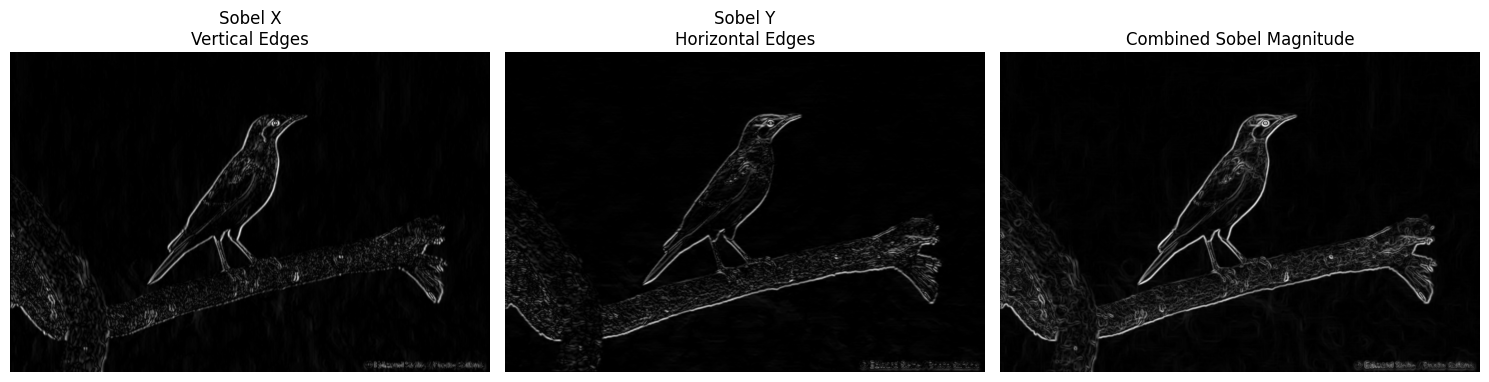

In [27]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(np.abs(sobel_x), cmap="gray")
plt.title("Sobel X\nVertical Edges")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.abs(sobel_y), cmap="gray")
plt.title("Sobel Y\nHorizontal Edges")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sobel_display, cmap="gray")
plt.title("Combined Sobel Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()

- Sobel does not simply return whether an edge exists.
- It also measures the strength and direction of intensity change.

## Method 2: Canny Edge Detection
Canny produces a clean binary edge map.

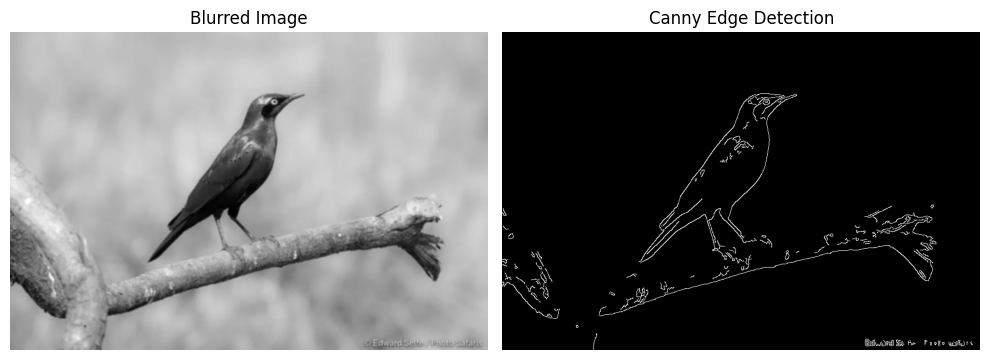

In [28]:
canny_edges =cv2.Canny(
    (blurred_img * 255).astype(np.uint8),
    threshold1=100,
    threshold2=200
)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(blurred_img, cmap="gray")
plt.title("Blurred Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(canny_edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

- Edges stronger than 200 are considered strong edges.
- Values below 100 are generally rejected.
- Values between them are retained only when connected to strong edges.

In [29]:
# Try with different Threshold values
canny_low = cv2.Canny(
    (blurred_img * 255).astype(np.uint8),
    50,
    100
)

canny_medium = cv2.Canny(
    (blurred_img * 255).astype(np.uint8),
    100,
    200
)

canny_high = cv2.Canny(
   (blurred_img * 255).astype(np.uint8),
    150,
    250
)

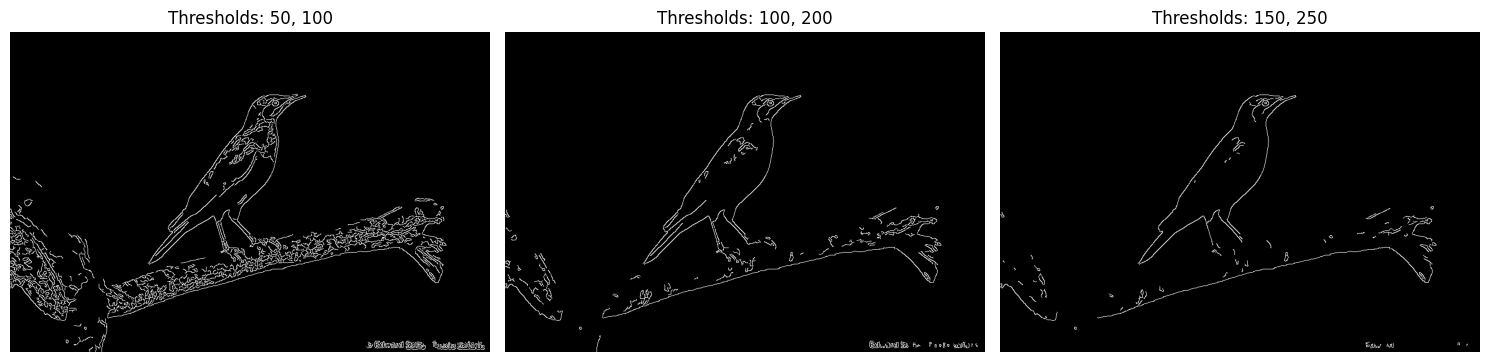

In [30]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(canny_low, cmap="gray")
plt.title("Thresholds: 50, 100")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(canny_medium, cmap="gray")
plt.title("Thresholds: 100, 200")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(canny_high, cmap="gray")
plt.title("Thresholds: 150, 250")
plt.axis("off")

plt.tight_layout()
plt.show()

- Lower thresholds usually detect more edges, including noise.
- Higher thresholds usually detect fewer but stronger edges.

## Method 3: Laplacian Edge Detection

In [31]:
laplacian = cv2.Laplacian(
    (blurred_img *255).astype(np.uint8),
    cv2.CV_64F
)

laplacian_display = cv2.convertScaleAbs(laplacian)

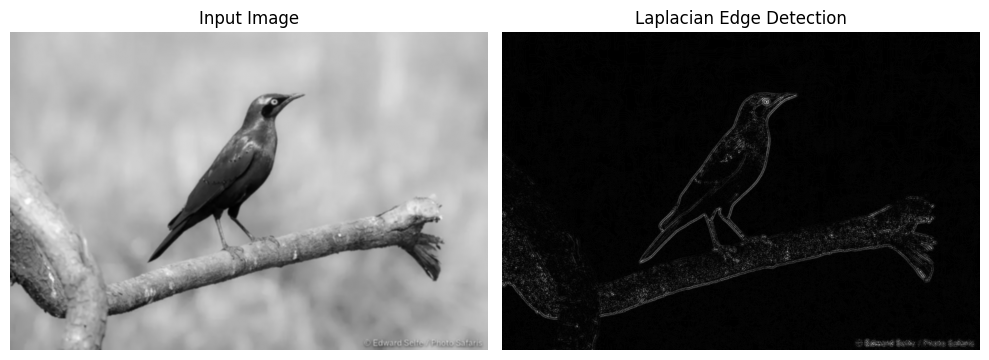

In [32]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow((blurred_img *255).astype(np.uint8), cmap="gray")
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(laplacian_display, cmap="gray")
plt.title("Laplacian Edge Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

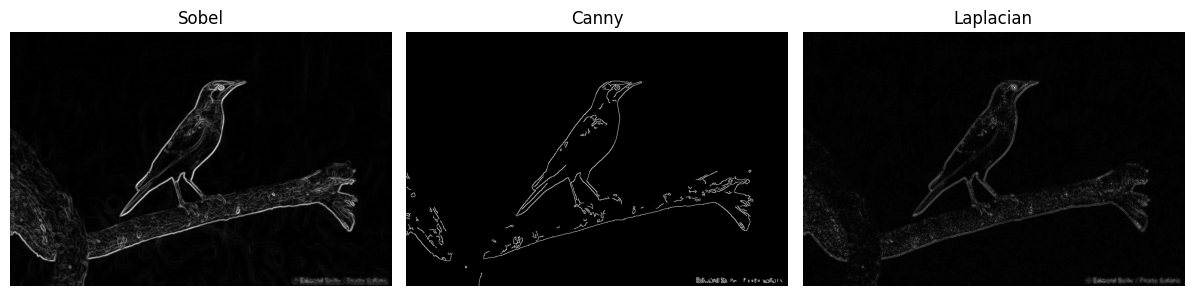

In [33]:
# Comparing all 3 methods
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 2)
plt.imshow(sobel_display, cmap="gray")
plt.title("Sobel")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(canny_edges, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(laplacian_display, cmap="gray")
plt.title("Laplacian")
plt.axis("off")

plt.tight_layout()
plt.show()

The machine-learning model needs numerical values such as:

- Number of edge pixels
- Percentage of the image occupied by edges
- Average edge strength
- Variation in edge strength

In [34]:
edge_pixel_count = np.count_nonzero(canny_edges)
total_pixel_count = canny_edges.size
edge_density = edge_pixel_count / total_pixel_count

print("Total pixels:", total_pixel_count)
print("Edge pixels:", edge_pixel_count)
print("Edge density:", round(edge_density, 4))

Total pixels: 492780
Edge pixels: 6521
Edge density: 0.0132


In [35]:
mean_sobel_strength = np.mean(sobel_magnitude)
std_sobel_strength = np.std(sobel_magnitude)

print(
    "Mean Sobel edge strength:",
    round(mean_sobel_strength, 4)
)

print(
    "Standard deviation of Sobel strength:",
    round(std_sobel_strength, 4)
)

Mean Sobel edge strength: 0.0634
Standard deviation of Sobel strength: 0.1397


In [36]:
edge_feature_vector = np.array([
    edge_pixel_count,
    edge_density,
    mean_sobel_strength,
    std_sobel_strength
])

print("Edge feature vector:")
print(edge_feature_vector)

print("\nFeature-vector shape:")
print(edge_feature_vector.shape)

Edge feature vector:
[6.52100000e+03 1.32330858e-02 6.34321434e-02 1.39679184e-01]

Feature-vector shape:
(4,)


## **2. Contours**
Contours as Shape Features
Contours work best when the foreground object is white and the background is black.

In [37]:
object_is_darker_than_background = True

In [38]:
if object_is_darker_than_background:
    threshold_type = cv2.THRESH_BINARY_INV
else:
    threshold_type = cv2.THRESH_BINARY

threshold_value, binary_img = cv2.threshold(
    (blurred_img * 255).astype(np.uint8),
    0,
    255,
    threshold_type + cv2.THRESH_OTSU
)

print("Automatically selected threshold:", threshold_value)

Automatically selected threshold: 129.0


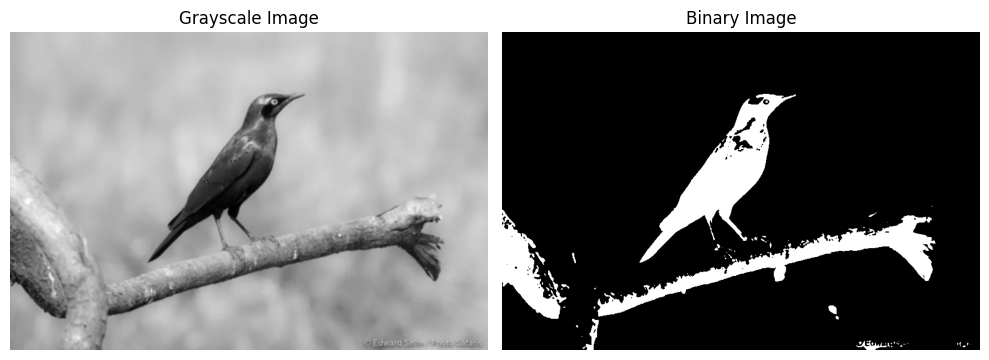

In [39]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow((blurred_img * 255).astype(np.uint8), cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(binary_img, cmap="gray")
plt.title("Binary Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [40]:
contours, hierarchy = cv2.findContours(
    binary_img,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Number of contours detected:", len(contours))

Number of contours detected: 76


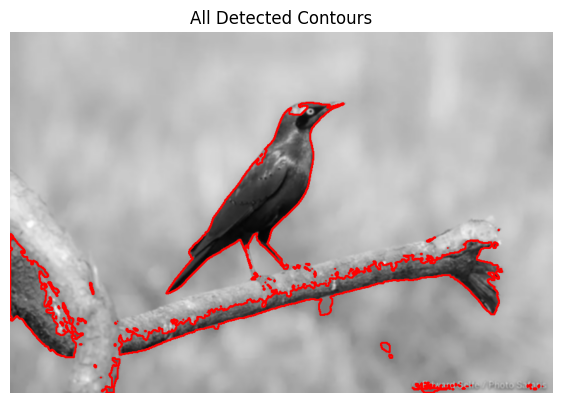

In [42]:
contour_image = cv2.cvtColor(
    (blurred_img * 255).astype(np.uint8),
    cv2.COLOR_GRAY2RGB
)

cv2.drawContours(
    contour_image,
    contours,
    -1,
    (255, 0, 0),
    2
)

plt.figure(figsize=(7, 6))
plt.imshow(contour_image)
plt.title("All Detected Contours")
plt.axis("off")
plt.show()

In [43]:
if len(contours) == 0:
    raise ValueError(
        "No contour was detected. Check the thresholded image."
    )

largest_contour = max(
    contours,
    key=cv2.contourArea
)

print(
    "Largest contour area:",
    cv2.contourArea(largest_contour)
)

Largest contour area: 22091.0


In [45]:
contour_area = cv2.contourArea(
    largest_contour
)

print("Contour area:", contour_area)

contour_perimeter = cv2.arcLength(
    largest_contour,
    True
)

print("Contour perimeter:", contour_perimeter)



Contour area: 22091.0
Contour perimeter: 1274.4448655843735


In [46]:
x, y, width, height = cv2.boundingRect(
    largest_contour
)

print("Bounding-box x:", x)
print("Bounding-box y:", y)
print("Bounding-box width:", width)
print("Bounding-box height:", height)

Bounding-box x: 247
Bounding-box y: 113
Bounding-box width: 282
Bounding-box height: 303


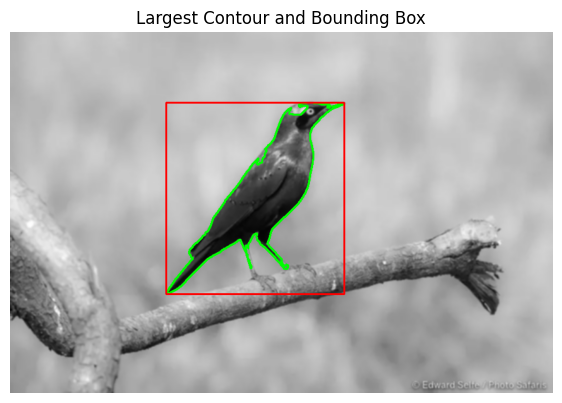

In [47]:
shape_image = cv2.cvtColor(
    (blurred_img * 255).astype(np.uint8),
    cv2.COLOR_GRAY2RGB
)

cv2.drawContours(
    shape_image,
    [largest_contour],
    -1,
    (0, 255, 0),
    2
)

cv2.rectangle(
    shape_image,
    (x, y),
    (x + width, y + height),
    (255, 0, 0),
    2
)

plt.figure(figsize=(7, 6))
plt.imshow(shape_image)
plt.title("Largest Contour and Bounding Box")
plt.axis("off")
plt.show()

In [48]:
if height > 0:
    aspect_ratio = width / height
else:
    aspect_ratio = 0

print("Aspect ratio:", round(aspect_ratio, 4))

if contour_perimeter > 0:
    circularity = (
        4
        * np.pi
        * contour_area
        / (contour_perimeter ** 2)
    )
else:
    circularity = 0

print("Circularity:", round(circularity, 4))

image_height, image_width = (blurred_img * 255).astype(np.uint8).shape

image_area = image_height * image_width

area_ratio = contour_area / image_area

bounding_box_width_ratio = width / image_width

bounding_box_height_ratio = height / image_height

normalized_perimeter = contour_perimeter / (
    2 * (image_width + image_height)
)

Aspect ratio: 0.9307
Circularity: 0.1709


In [49]:
contour_feature_vector = np.array([
    area_ratio,
    normalized_perimeter,
    aspect_ratio,
    circularity,
    bounding_box_width_ratio,
    bounding_box_height_ratio
])

print("Contour feature vector:")
print(contour_feature_vector)

print("\nFeature-vector shape:")
print(contour_feature_vector.shape)

Contour feature vector:
[0.04482934 0.4446772  0.93069307 0.17091616 0.32790698 0.52879581]

Feature-vector shape:
(6,)


In [50]:
features = {
    "edge_pixel_count": edge_pixel_count,
    "edge_density": edge_density,
    "mean_sobel_strength": mean_sobel_strength,
    "std_sobel_strength": std_sobel_strength,
    "contour_area_ratio": area_ratio,
    "normalized_perimeter": normalized_perimeter,
    "aspect_ratio": aspect_ratio,
    "circularity": circularity,
    "bbox_width_ratio": bounding_box_width_ratio,
    "bbox_height_ratio": bounding_box_height_ratio
}

In [51]:
import pandas as pd
feature_table = pd.DataFrame(
    features.items(),
    columns=["Feature", "Value"]
)

feature_table

,Feature,Value
0,edge_pixel_count,6521.000000
1,edge_density,0.013233
2,mean_sobel_strength,0.063432
3,std_sobel_strength,0.139679
4,contour_area_ratio,0.044829
5,normalized_perimeter,0.444677
6,aspect_ratio,0.930693
7,circularity,0.170916
8,bbox_width_ratio,0.327907
9,bbox_height_ratio,0.528796


In [52]:
final_feature_vector = np.array(
    list(features.values()),
    dtype=np.float32
)

raw_pixel_features = (blurred_img * 255).astype(np.uint8).flatten()

print(
    "Number of raw pixel features:",
    raw_pixel_features.size
)

print(
    "Number of handcrafted features:",
    final_feature_vector.size
)

Number of raw pixel features: 492780
Number of handcrafted features: 10


This does not mean that ten features are always better than raw pixels.

It means that the extracted features are:

- More compact
- Easier to interpret
- Focused on edges and shape
- Potentially less sensitive to irrelevant pixel variations

> The usefulness of the features depends on the classification problem.

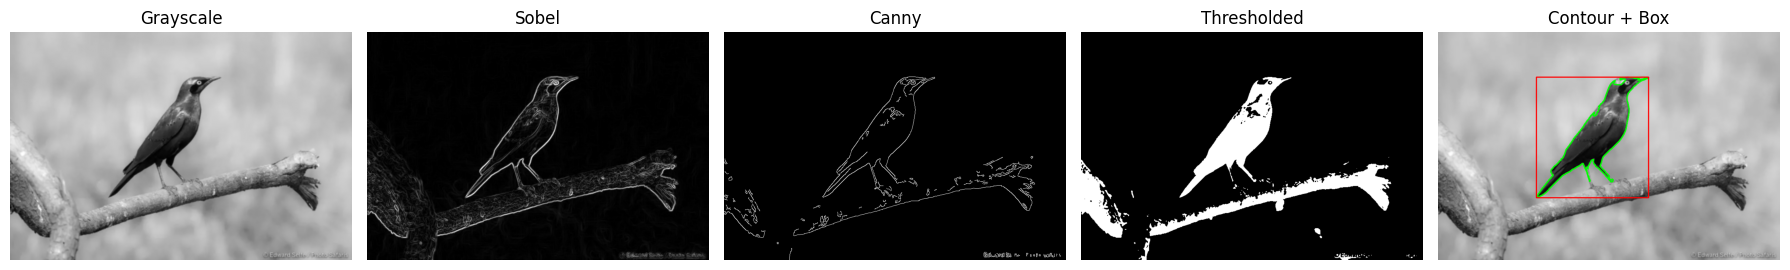

In [53]:
plt.figure(figsize=(18, 4))

plt.subplot(1, 5, 1)
plt.imshow((blurred_img * 255).astype(np.uint8), cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(sobel_display, cmap="gray")
plt.title("Sobel")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(canny_edges, cmap="gray")
plt.title("Canny")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(binary_img, cmap="gray")
plt.title("Thresholded")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(shape_image)
plt.title("Contour + Box")
plt.axis("off")

plt.tight_layout()
plt.show()

----------------------------------------------------------------------------------------------------------------------------------------------------------------

# Part 3 - Model training

In [1]:
import random
from pathlib import Path
import os
import cv2
import kagglehub
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

##  **1. Load the dataset**

In [ ]:
# Dowmload the shapes dataset from Kaggle
path = kagglehub.dataset_download("khalidboussaroual/2d-geometric-shapes-17-shapes")
dataset_path = Path(path)

print("Dataset path:")
print(dataset_path)

print("\nDoes the dataset exist?")
print(dataset_path.exists())

Using Colab cache for faster access to the '2d-geometric-shapes-17-shapes' dataset.
Dataset path:
/kaggle/input/2d-geometric-shapes-17-shapes

Does the dataset exist?
True


In [ ]:
# Out of 10+ different shapes present in the database, let's select a few just for faster preprocessing

selected_classes = [
    "circle",
    "square",
    "triangle"
]

class_folders = {}

for current_folder, subfolders, files in os.walk(dataset_path):

    for folder_name in subfolders:

        folder_name_lower = folder_name.lower()

        if folder_name_lower in selected_classes:

            class_folders[folder_name_lower] = (
                Path(current_folder) / folder_name
            )

    if len(class_folders) == len(selected_classes):
        break

print("Class folders found:")
for class_name in selected_classes:
    if class_name in class_folders:
        print(
            f"{class_name}: "
            f"{class_folders[class_name]}"
        )
    else:
        print(
            f"{class_name}: NOT FOUND"
        )

Class folders found:
circle: /kaggle/input/2d-geometric-shapes-17-shapes/2D_Geometric_Shapes_Dataset/circle
square: /kaggle/input/2d-geometric-shapes-17-shapes/2D_Geometric_Shapes_Dataset/square
triangle: /kaggle/input/2d-geometric-shapes-17-shapes/2D_Geometric_Shapes_Dataset/triangle


In [ ]:
images_per_class = 1000
random.seed(42)

selected_images = []

for class_name in selected_classes:
  folder_path = class_folders[class_name]
  image_paths = list(
    folder_path.rglob("*.png"))

  print(
        f"{class_name}: "
        f"{len(image_paths)} images available"
    )

  number_to_select = min(
        images_per_class,
        len(image_paths)
    )

  sampled_paths = random.sample(
        image_paths,
        number_to_select
    )

  for image_path in sampled_paths:
        selected_images.append(
            (image_path, class_name)
        )

print(
    "\nTotal images selected:",
    len(selected_images)
)

circle: 50000 images available
square: 50000 images available
triangle: 50000 images available

Total images selected: 3000


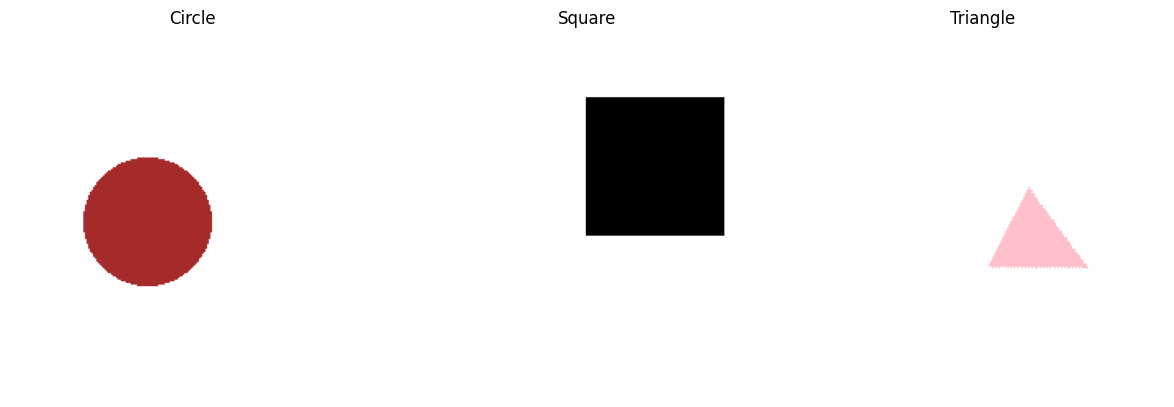

In [ ]:
plt.figure(figsize=(12, 4))

# Loop through each selected class and display one sample image
for index, class_name in enumerate(
    selected_classes,
    start=1
):
    # Find the first image belonging to the current class
    sample_path = next(
        image_path
        for image_path, label in selected_images
        if label == class_name
    )

    image_bgr = cv2.imread(
        str(sample_path)
    )

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(1, 3, index)

    plt.imshow(image_rgb)

    plt.title(
        class_name.capitalize()
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## **2. Image Preprocessing and Feature Extraction**

Let's perform all the Image Processing steps and Feature Extraction we did preciously on single images

In [ ]:
def extract_features(
    image_path,
    image_size=(128, 128)
):
    """
    Extract simple shape and edge features
    from one geometric-shape image.

    Parameters
    ----------
    image_path : Path or str
        Location of the image.

    image_size : tuple
        Width and height used for resizing.

    Returns
    -------
    dict or None
        Dictionary containing extracted features.
        Returns None when the image cannot be processed.
    """

    # 1. Read the image
    image = cv2.imread(
        str(image_path)
    )

    if image is None:
        return None


    # 2. Resize the image
    image = cv2.resize(
        image,
        image_size
    )

    # 3. Convert to grayscale
    grayscale = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )


    # 4. Create a binary mask
    # The dataset has a white background.
    # Pixels different from white are
    # considered part of the shape.

    white_image = np.full_like(
        image,
        255
    )

    difference_from_white = cv2.absdiff(
        image,
        white_image
    )

    maximum_difference = np.max(
        difference_from_white,
        axis=2
    )

    binary_image = np.where(
        maximum_difference > 10,
        255,
        0
    ).astype(np.uint8)

    # Smooth small gaps in the shape mask
    kernel = np.ones(
        (3, 3),
        dtype=np.uint8
    )

    binary_image = cv2.morphologyEx(
        binary_image,
        cv2.MORPH_CLOSE,
        kernel
    )

    # 5. Find contours
    contours, _ = cv2.findContours(
        binary_image,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return None

    # Select the main shape

    largest_contour = max(
        contours,
        key=cv2.contourArea
    )

    # 6. Area feature
    contour_area = cv2.contourArea(
        largest_contour
    )

    image_height, image_width = (
        grayscale.shape
    )

    total_image_area = (
        image_height * image_width
    )

    area_ratio = (
        contour_area / total_image_area
    )


    # 7. Perimeter feature
    contour_perimeter = cv2.arcLength(
        largest_contour,
        True
    )

    maximum_possible_perimeter = (
        2 * (image_width + image_height)
    )

    perimeter_ratio = (
        contour_perimeter
        / maximum_possible_perimeter
    )

    # 8. Bounding box
    x, y, width, height = cv2.boundingRect(
        largest_contour
    )

    if height > 0:
        aspect_ratio = width / height
    else:
        aspect_ratio = 0.0


    # 9. Circularity
    if contour_perimeter > 0:
        circularity = (
            4
            * np.pi
            * contour_area
            / (contour_perimeter ** 2)
        )

    else:
        circularity = 0.0

    # 10. Extent
    # Area occupied inside the bounding box

    bounding_box_area = width * height

    if bounding_box_area > 0:
        extent = (
            contour_area
            / bounding_box_area
        )
    else:
        extent = 0.0


    # 11. Solidity
    # Compares the contour with its
    # convex hull

    convex_hull = cv2.convexHull(
        largest_contour
    )

    convex_hull_area = cv2.contourArea(
        convex_hull
    )

    if convex_hull_area > 0:
        solidity = (
            contour_area
            / convex_hull_area
        )
    else:
        solidity = 0.0


    # 12. Approximate number of corners
    epsilon = (
        0.02 * contour_perimeter
    )

    approximated_contour = (
        cv2.approxPolyDP(
            largest_contour,
            epsilon,
            True
        )
    )

    number_of_corners = len(
        approximated_contour
    )

    # 13. Edge density
    blurred_image = cv2.GaussianBlur(
        grayscale,
        (5, 5),
        0
    )

    edge_image = cv2.Canny(
        blurred_image,
        50,
        150
    )

    number_of_edge_pixels = (
        np.count_nonzero(edge_image)
    )

    edge_density = (
        number_of_edge_pixels
        / edge_image.size
    )

    # 14. Return all features
    features = {
        "area_ratio": area_ratio,
        "perimeter_ratio": perimeter_ratio,
        "aspect_ratio": aspect_ratio,
        "circularity": circularity,
        "extent": extent,
        "solidity": solidity,
        "number_of_corners": number_of_corners,
        "edge_density": edge_density
    }

    return features

In [ ]:
# check if the fucntion is working as expected by testing on one smaple image
sample_path, sample_label = (
    selected_images[0]
)

sample_features = extract_features(
    sample_path
)

print("Image class:", sample_label)
print("Image path:", sample_path)

print("\nExtracted features:")

for feature_name, feature_value in (
    sample_features.items()
):

    print(
        f"{feature_name}: "
        f"{feature_value:.4f}"
    )

Image class: circle
Image path: /kaggle/input/2d-geometric-shapes-17-shapes/2D_Geometric_Shapes_Dataset/circle/circle_39580.png

Extracted features:
area_ratio: 0.0962
perimeter_ratio: 0.2905
aspect_ratio: 1.0222
circularity: 0.8955
extent: 0.7614
solidity: 0.9853
number_of_corners: 8.0000
edge_density: 0.0099


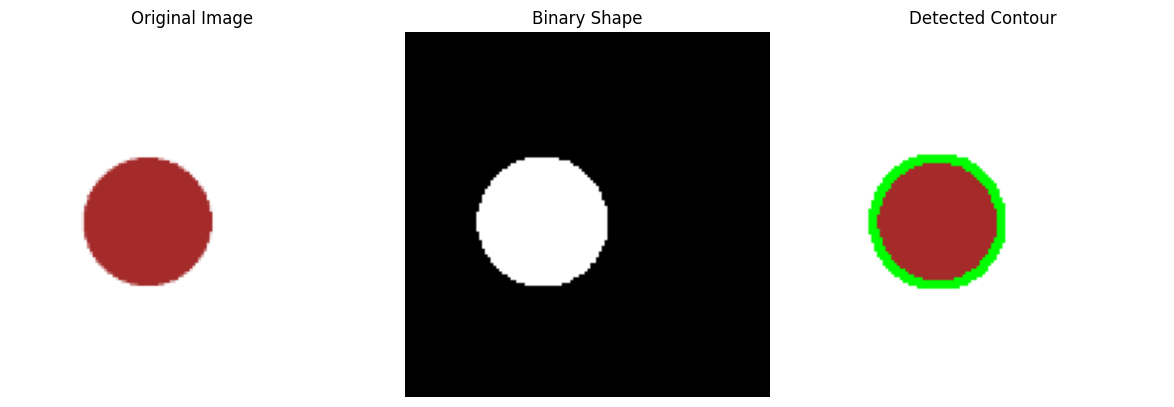

In [ ]:
def display_feature_extraction(image_path):
    image_bgr = cv2.imread(
        str(image_path)
    )
    image_bgr = cv2.resize(
        image_bgr,
        (128, 128)
    )

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    white_image = np.full_like(
        image_bgr,
        255
    )

    difference = cv2.absdiff(
        image_bgr,
        white_image
    )

    maximum_difference = np.max(
        difference,
        axis=2
    )

    binary_image = np.where(
        maximum_difference > 10,
        255,
        0
    ).astype(np.uint8)

    contours, _ = cv2.findContours(
        binary_image,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contour_image = image_rgb.copy()

    if contours:

        largest_contour = max(
            contours,
            key=cv2.contourArea
        )

        cv2.drawContours(
            contour_image,
            [largest_contour],
            -1,
            (0, 255, 0),
            2
        )

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(
        binary_image,
        cmap="gray"
    )
    plt.title("Binary Shape")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(contour_image)
    plt.title("Detected Contour")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


display_feature_extraction(
    sample_path
)

In [ ]:
# Now that things are working fine, let's apply the FE process to all the 3K images
feature_rows = []

total_images = len(
    selected_images
)

for image_number, (
    image_path,
    class_label
) in enumerate(
    selected_images,
    start=1
):

    features = extract_features(
        image_path
    )

    if features is not None:

        features["label"] = class_label

        features["image_path"] = str(
            image_path
        )

        feature_rows.append(
            features
        )

    if image_number % 500 == 0:

        print(
            f"Processed "
            f"{image_number}/"
            f"{total_images} images"
        )

Processed 500/3000 images
Processed 1000/3000 images
Processed 1500/3000 images
Processed 2000/3000 images
Processed 2500/3000 images
Processed 3000/3000 images


In [ ]:
feature_df = pd.DataFrame(
    feature_rows
)

print(
    "Feature dataset shape:",
    feature_df.shape
)

feature_df.head()

Feature dataset shape: (3000, 10)


,area_ratio,perimeter_ratio,aspect_ratio,circularity,extent,solidity,number_of_corners,edge_density,label,image_path
0,0.096191,0.290451,1.022222,0.895533,0.761353,0.985308,8,0.009949,circle,/kaggle/input/2d-geometric-shapes-17-shapes/2D...
1,0.162415,0.377613,1.000000,0.894581,0.764436,0.986835,8,0.013000,circle,/kaggle/input/2d-geometric-shapes-17-shapes/2D...
2,0.220123,0.440865,1.000000,0.889497,0.757509,0.986731,8,0.015381,circle,/kaggle/input/2d-geometric-shapes-17-shapes/2D...
3,0.122681,0.326555,1.000000,0.903555,0.772780,0.985777,8,0.011108,circle,/kaggle/input/2d-geometric-shapes-17-shapes/2D...
4,0.128357,0.334367,1.000000,0.901700,0.777737,0.985012,8,0.011719,circle,/kaggle/input/2d-geometric-shapes-17-shapes/2D...


In [ ]:
# Quick glaance at the feature extracted tabular data
print("Images in each class:")

print(
    feature_df["label"]
    .value_counts()
)

print("\nMissing values:")

print(
    feature_df.isnull().sum()
)

feature_df.describe()

Images in each class:
label
circle      1000
square      1000
triangle    1000
Name: count, dtype: int64

Missing values:
area_ratio           0
perimeter_ratio      0
aspect_ratio         0
circularity          0
extent               0
solidity             0
number_of_corners    0
edge_density         0
label                0
image_path           0
dtype: int64


,area_ratio,perimeter_ratio,aspect_ratio,circularity,extent,solidity,number_of_corners,edge_density
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.164217,0.399711,1.004592,0.735650,0.727234,0.975787,5.001333,0.011225
std,0.102025,0.121195,0.074280,0.150443,0.207436,0.025703,2.161378,0.005873
min,0.024384,0.182138,0.788732,0.497821,0.407237,0.894737,3.000000,0.000000
25%,0.081299,0.296875,0.988095,0.538936,0.469362,0.954317,3.000000,0.008057
50%,0.141769,0.397382,1.000000,0.785398,0.762041,0.985164,4.000000,0.011902
75%,0.227081,0.495356,1.013202,0.882953,0.954545,1.000000,8.000000,0.015869
max,0.451416,0.671875,1.269231,0.926020,0.977144,1.000000,9.000000,0.020935


In [ ]:
feature_names = [
    "area_ratio",
    "perimeter_ratio",
    "aspect_ratio",
    "circularity",
    "extent",
    "solidity",
    "number_of_corners",
    "edge_density"
]

X = feature_df[
    feature_names
]

y = feature_df[
    "label"
]

print(
    "Feature matrix X:",
    X.shape
)

print(
    "Target vector y:",
    y.shape
)

Feature matrix X: (3000, 8)
Target vector y: (3000,)


## **3. Train-Test split**

In [ ]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

Training samples: 2400
Testing samples: 600


In [ ]:
# Quick glance at the Training and Test Class distribution
print("Training class distribution:")

print(
    y_train.value_counts()
)

print("\nTesting class distribution:")

print(
    y_test.value_counts()
)

Training class distribution:
label
triangle    800
circle      800
square      800
Name: count, dtype: int64

Testing class distribution:
label
triangle    200
square      200
circle      200
Name: count, dtype: int64


In [ ]:
# Prepare the Logistic Regresion Model Pipeline
logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "logistic_regression",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

## **4. Logistic Regression Model**

In [ ]:
# Fit the Training Model
logistic_model.fit(
    X_train,
    y_train
)

print(
    "Logistic Regression training completed."
)

Logistic Regression training completed.


## **5. Make Predictions**

In [ ]:
y_pred = logistic_model.predict(
    X_test
)

print("First 10 predictions:")

print(
    y_pred[:10]
)

prediction_table = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": y_pred
})

prediction_table.head(10)

First 10 predictions:
['triangle' 'triangle' 'square' 'circle' 'triangle' 'triangle' 'circle'
 'square' 'triangle' 'square']


,Actual,Predicted
0,triangle,triangle
1,triangle,triangle
2,square,square
3,circle,circle
4,triangle,triangle
5,triangle,triangle
6,circle,circle
7,square,square
8,triangle,triangle
9,square,square


## **6. Model Eval**

In [ ]:
training_accuracy = (
    logistic_model.score(
        X_train,
        y_train
    )
)

testing_accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Training Accuracy: "
    f"{training_accuracy:.2%}"
)

print(
    f"Testing Accuracy: "
    f"{testing_accuracy:.2%}"
)

#Classification Report
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


Training Accuracy: 100.00%
Testing Accuracy: 100.00%
              precision    recall  f1-score   support

      circle       1.00      1.00      1.00       200
      square       1.00      1.00      1.00       200
    triangle       1.00      1.00      1.00       200

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



In [ ]:
# Each image/class gets 3 prob scores.
#Higher the score on any class indicates the shape of the image
class_probabilities = (
    logistic_model.predict_proba(
        X_test
    )
)

class_names = (
    logistic_model
    .named_steps[
        "logistic_regression"
    ]
    .classes_
)

print("Class order:")

print(
    class_names
)

print(
    "\nProbability array shape:",
    class_probabilities.shape
)

Class order:
['circle' 'square' 'triangle']

Probability array shape: (600, 3)


In [ ]:
sample_number = 0 # can try different sample nums to get differnt shape preds

print(
    "Actual class:",
    y_test.iloc[sample_number]
)

print(
    "Predicted class:",
    y_pred[sample_number]
)

print("\nClass probabilities:")

for class_name, probability in zip(
    class_names,
    class_probabilities[sample_number]
):

    print(
        f"{class_name}: "
        f"{probability:.2%}"
    )

Actual class: triangle
Predicted class: triangle

Class probabilities:
circle: 0.01%
square: 0.00%
triangle: 99.99%


In [ ]:
# display the same in tabular format
probability_columns = [
    f"P({class_name})"
    for class_name in class_names
]

probability_df = pd.DataFrame(
    class_probabilities,
    columns=probability_columns,
    index=X_test.index
)

results_df = pd.DataFrame(
    {
        "Actual": y_test,
        "Predicted": y_pred,
        "Confidence": (
            class_probabilities.max(
                axis=1
            )
        )
    },
    index=X_test.index
)

results_df = pd.concat(
    [
        results_df,
        probability_df
    ],
    axis=1
)

results_df.head(10)

,Actual,Predicted,Confidence,P(circle),P(square),P(triangle)
2664,triangle,triangle,0.999859,0.000106,0.000035,0.999859
2416,triangle,triangle,0.999190,0.000300,0.000511,0.999190
1813,square,square,0.998284,0.001244,0.998284,0.000473
690,circle,circle,0.998075,0.998075,0.001669,0.000255
2839,triangle,triangle,0.999784,0.000133,0.000083,0.999784
2871,triangle,triangle,0.999840,0.000144,0.000016,0.999840
565,circle,circle,0.998945,0.998945,0.000726,0.000328
1348,square,square,0.997860,0.001527,0.997860,0.000613
2793,triangle,triangle,0.999136,0.000287,0.000577,0.999136
1404,square,square,0.997805,0.001558,0.997805,0.000637


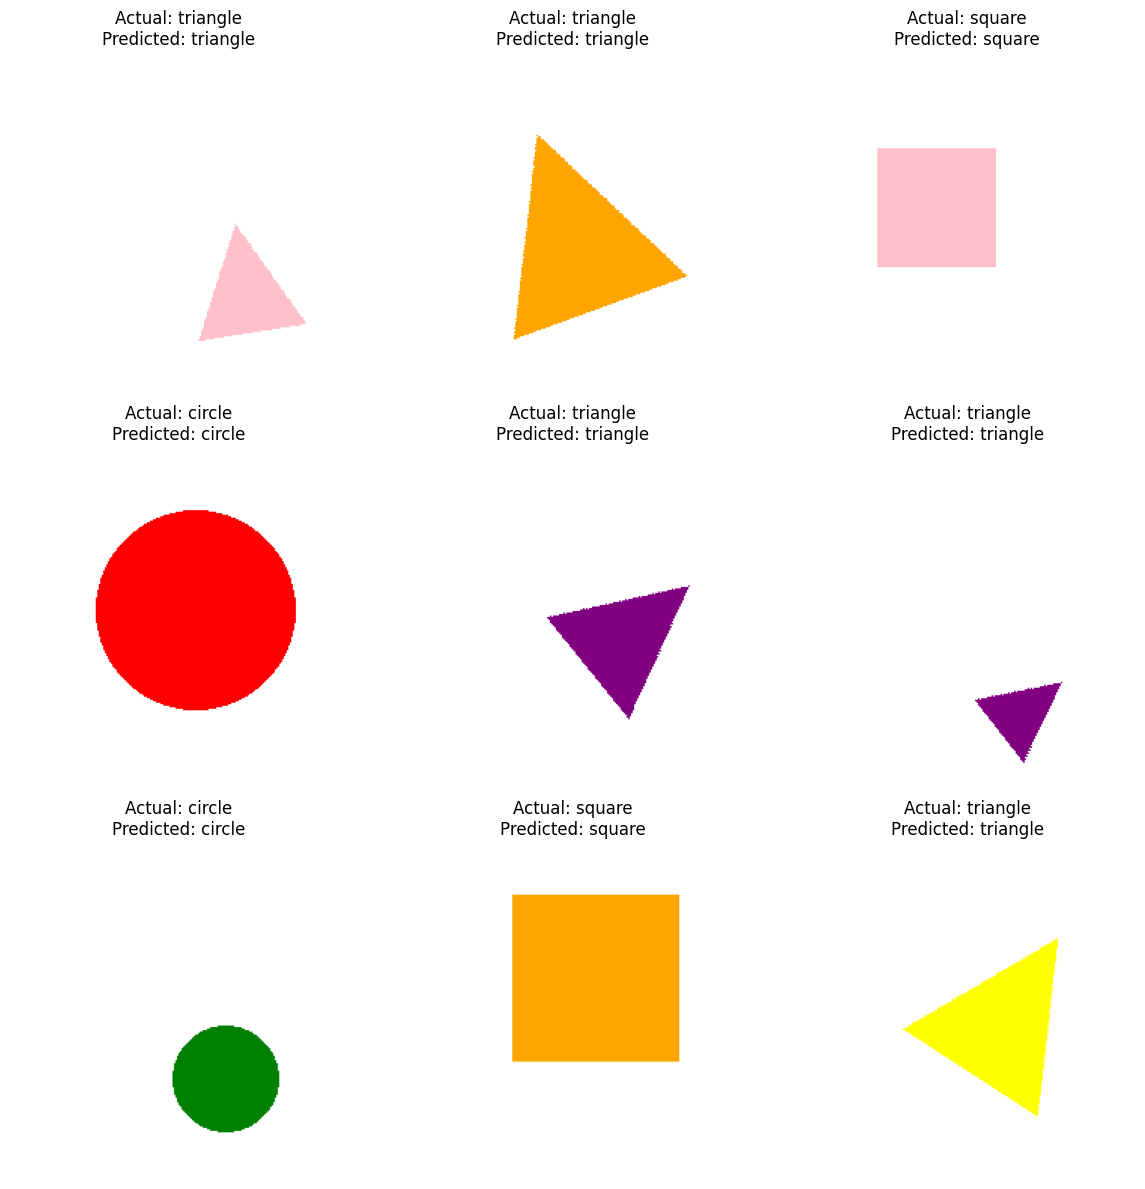

In [ ]:
#Display several test predictions
number_of_images = 9

sample_indices = list(
    X_test.index[:number_of_images]
)

plt.figure(figsize=(12, 12))

for plot_number, sample_index in enumerate(
    sample_indices,
    start=1
):

    image_path = feature_df.loc[
        sample_index,
        "image_path"
    ]

    image_bgr = cv2.imread(
        image_path
    )

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    actual = y_test.loc[
        sample_index
    ]

    predicted = logistic_model.predict(
        X_test.loc[[sample_index]]
    )[0]

    plt.subplot(
        3,
        3,
        plot_number
    )

    plt.imshow(
        image_rgb
    )

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# check if any incorrect predictions are made
incorrect_results = results_df[
    results_df["Actual"]
    != results_df["Predicted"]
]

print(
    "Number of incorrect predictions:",
    len(incorrect_results)
)

incorrect_results.head(10)

Number of incorrect predictions: 0


,Actual,Predicted,Confidence,P(circle),P(square),P(triangle)


## **7. Prediction on a new image**

In [ ]:
import requests

from io import BytesIO
from PIL import Image

Image downloaded successfully.


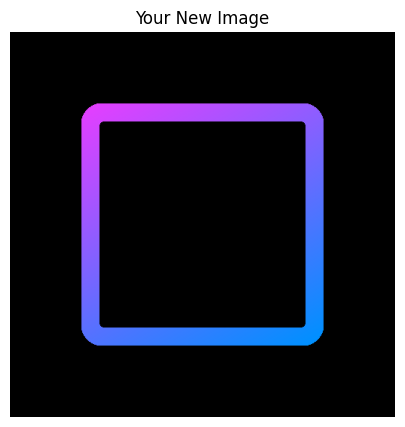

In [ ]:
new_image_url = 'https://cdn-icons-png.flaticon.com/512/7554/7554093.png'

try:
    response = requests.get(
        new_image_url,
        headers={
            "User-Agent": "Mozilla/5.0"
        },
        timeout=20
    )

    response.raise_for_status()

    # Read the downloaded image
    downloaded_image = Image.open(
        BytesIO(response.content)
    ).convert("RGB")

    print("Image downloaded successfully.")

    plt.figure(figsize=(6, 5))
    plt.imshow(downloaded_image)
    plt.title("Your New Image")
    plt.axis("off")
    plt.show()

except Exception as error:
    print("Could not download the image.")
    print("Error:", error)
    print(
        "Make sure you copied the direct image address, "
        "not the webpage address."
    )

In [ ]:
new_image_path = "my_new_image.jpg"

downloaded_image.save(
    new_image_path
)

print(
    "Image saved as:",
    new_image_path
)

Image saved as: my_new_image.jpg


In [ ]:
# Apply Feature Engineering on the new image
new_features = extract_features(
    new_image_path
)

if new_features is None:
    raise ValueError(
        "No clear shape was detected in the image. "
        "Try an image with one shape and a simple background."
    )

print("Extracted features:")

for feature_name, feature_value in (
    new_features.items()
):
    print(
        f"{feature_name}: "
        f"{feature_value:.4f}"
    )

Extracted features:
area_ratio: 0.9844
perimeter_ratio: 0.9922
aspect_ratio: 1.0000
circularity: 0.7854
extent: 0.9844
solidity: 1.0000
number_of_corners: 4.0000
edge_density: 0.0356


In [ ]:
new_image_df = pd.DataFrame(
    [new_features]
)

# Keep the columns in the same order
# used while training the model
new_image_df = new_image_df[
    feature_names
]

new_image_df

,area_ratio,perimeter_ratio,aspect_ratio,circularity,extent,solidity,number_of_corners,edge_density
0,0.984436,0.992188,1.0,0.785398,0.984436,1.0,4,0.035645


In [ ]:
# Get predictions on the new image
predicted_class = logistic_model.predict(
    new_image_df
)[0]

predicted_probabilities = (
    logistic_model.predict_proba(
        new_image_df
    )[0]
)

print(
    "Predicted shape:",
    predicted_class
)

Predicted shape: square


In [ ]:
class_names = (
    logistic_model
    .named_steps[
        "logistic_regression"
    ]
    .classes_
)

print("Prediction probabilities:\n")

for class_name, probability in zip(
    class_names,
    predicted_probabilities
):
    print(
        f"{class_name}: "
        f"{probability:.2%}"
    )

Prediction probabilities:

circle: 0.21%
square: 99.77%
triangle: 0.02%


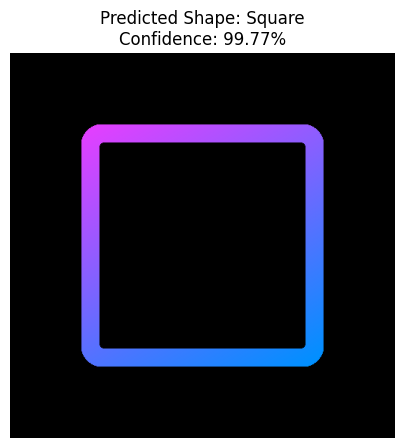

In [ ]:
highest_probability = (
    predicted_probabilities.max()
)

plt.figure(figsize=(6, 5))

plt.imshow(downloaded_image)

plt.title(
    f"Predicted Shape: "
    f"{predicted_class.capitalize()}\n"
    f"Confidence: "
    f"{highest_probability:.2%}"
)

plt.axis("off")
plt.show()

Predicted shape: square

Class probabilities:
circle: 0.21%
square: 99.77%
triangle: 0.02%


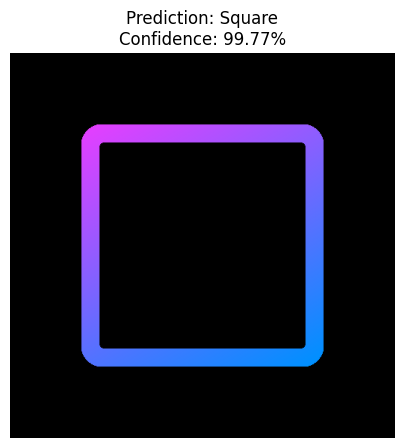

In [ ]:
# One shot Prediction code
# --------------------------------------
# 1. Paste a direct image URL
# --------------------------------------

new_image_url = "https://cdn-icons-png.flaticon.com/512/7554/7554093.png"


# --------------------------------------
# 2. Download the image
# --------------------------------------

response = requests.get(
    new_image_url,
    headers={
        "User-Agent": "Mozilla/5.0"
    },
    timeout=20
)

response.raise_for_status()

downloaded_image = Image.open(
    BytesIO(response.content)
).convert("RGB")


# --------------------------------------
# 3. Save temporarily
# --------------------------------------

new_image_path = "student_new_image.jpg"

downloaded_image.save(
    new_image_path
)


# --------------------------------------
# 4. Extract the same features
# --------------------------------------

new_features = extract_features(
    new_image_path
)

if new_features is None:
    raise ValueError(
        "No clear shape was detected. "
        "Try another image."
    )


# --------------------------------------
# 5. Convert to model input
# --------------------------------------

new_image_df = pd.DataFrame(
    [new_features]
)

new_image_df = new_image_df[
    feature_names
]


# --------------------------------------
# 6. Predict class and probabilities
# --------------------------------------

predicted_class = logistic_model.predict(
    new_image_df
)[0]

predicted_probabilities = (
    logistic_model.predict_proba(
        new_image_df
    )[0]
)

class_names = (
    logistic_model
    .named_steps[
        "logistic_regression"
    ]
    .classes_
)


# --------------------------------------
# 7. Print results
# --------------------------------------

print(
    "Predicted shape:",
    predicted_class
)

print("\nClass probabilities:")

for class_name, probability in zip(
    class_names,
    predicted_probabilities
):
    print(
        f"{class_name}: "
        f"{probability:.2%}"
    )


# --------------------------------------
# 8. Display the prediction
# --------------------------------------

confidence = (
    predicted_probabilities.max()
)

plt.figure(figsize=(6, 5))

plt.imshow(downloaded_image)

plt.title(
    f"Prediction: "
    f"{predicted_class.capitalize()}\n"
    f"Confidence: "
    f"{confidence:.2%}"
)

plt.axis("off")
plt.show()

In [ ]:

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

denoised = cv2.fastNlMeansDenoising(img)

flat = img.flatten()





grayscale_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2GRAY)
